In [18]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm import tqdm
# from extract_features import GenerateFeatures
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import scale, StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE





Normalize the train data and applied the normalization params to the test set

In [19]:
train_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/3_class/train_set/two_class_3s_no.csv'
test_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/3_class/test_set/two_class_3s_no.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


train_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
test_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']


View label distribution

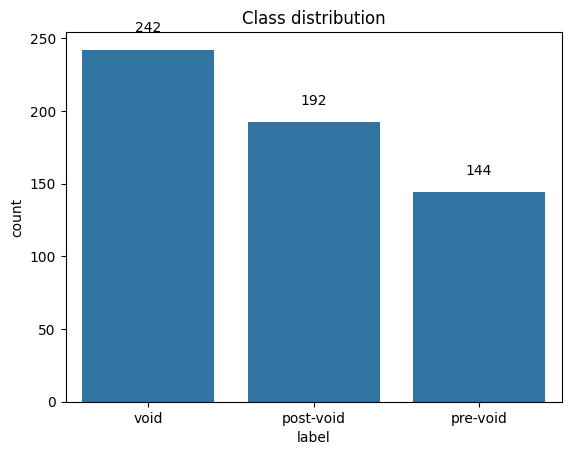

In [20]:
plt.figure()
ax = sns.countplot(x='label',
                   data=train_data,
                   order=train_data.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()


In [21]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
# y_train_encoded = label_encoder.fit_transform(y_train_smote) 
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [22]:
# model = XGBClassifier(random_state = 42)
model = RandomForestClassifier(random_state=42)

In [23]:
from sklearn import set_config
set_config(display="text")  # avoids estimator_html_repr

In [24]:
# eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)
model.fit(X_train, y_train_encoded)

RandomForestClassifier(random_state=42)

In [25]:
classes = ['pre-void','void', 'post-void']

In [26]:
y_pred = label_encoder.inverse_transform(model.predict(X_test))
# y_pred = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)

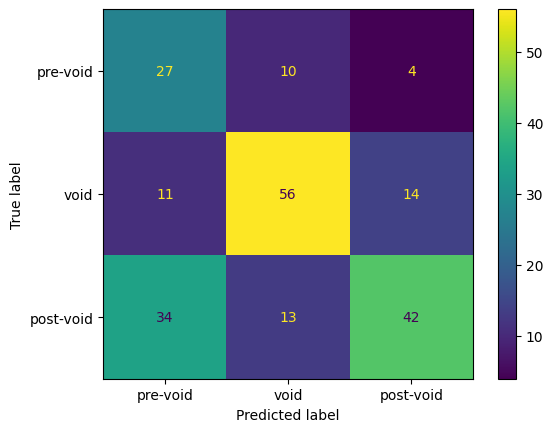

              precision    recall  f1-score   support

    pre-void       0.38      0.66      0.48        41
        void       0.71      0.69      0.70        81
   post-void       0.70      0.47      0.56        89

    accuracy                           0.59       211
   macro avg       0.59      0.61      0.58       211
weighted avg       0.64      0.59      0.60       211



In [27]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()


# Classification report
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred, labels=classes)

print(report)

In [28]:
report_dict = classification_report(y_test, y_pred, output_dict=True)


In [29]:
# # Retrieve the evaluation results
# results = model.evals_result()
# train_loss = results['validation_0']['mlogloss']
# test_loss = results['validation_1']['mlogloss']

# # Plot the loss function
# plt.figure(figsize=(10, 6))
# plt.plot(train_loss, label='Training Loss')
# plt.plot(test_loss, label='Validation Loss')
# plt.xlabel('Training Rounds')
# plt.ylabel('Log Loss')
# plt.title('3s sliding window, 0.5 overlap, smote')
# plt.legend()
# plt.grid(True)
# # plt.savefig('model_plots/two_class_results/loss_3s_0.5_smote.png')
# plt.show()

In [30]:
plot_importance(model)
plt.show()

ValueError: tree must be Booster, XGBModel or dict instance

1. For every file in the train and test.
2. Call the tune_hyperparameters function.
3. tune_hyperparameters has the train set of a particular dataset as an argument. 
4. tune_hyperparameters returns the hyperparameters tuned for each model that maximizes accuracy.

## 2 class

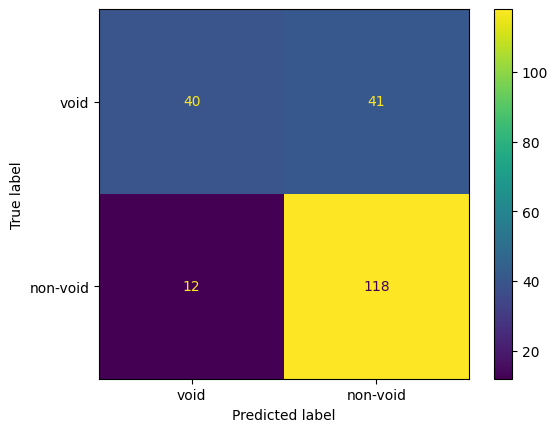

              precision    recall  f1-score   support

        void       0.77      0.49      0.60        81
    non-void       0.74      0.91      0.82       130

    accuracy                           0.75       211
   macro avg       0.76      0.70      0.71       211
weighted avg       0.75      0.75      0.73       211



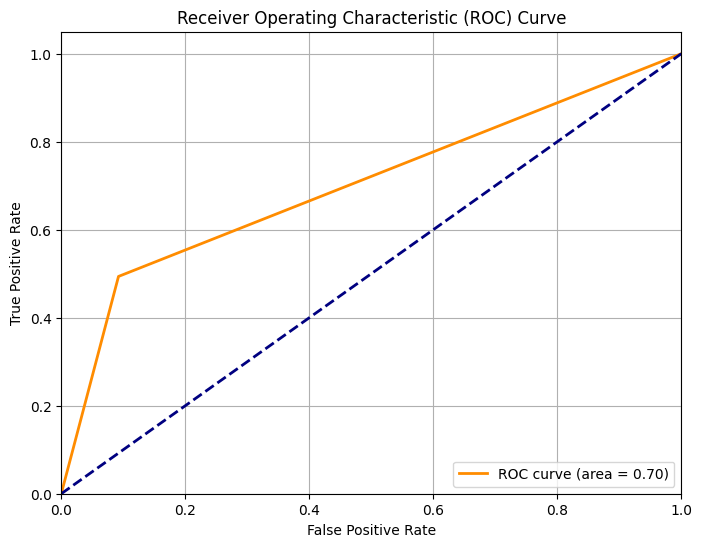

In [ ]:
train_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/2_class/train_set/two_class_3s_no.csv'
test_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/deployable/data/extracted_features_data/2_class/test_set/two_class_3s_no.csv'

train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)


train_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
test_data.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)

X_train = train_data.drop(columns=['label', 'experiment_id'])
y_train = train_data['label']

X_test = test_data.drop(columns=['label', 'experiment_id'])
y_test = test_data['label']


# Encode y_test and y_train
label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train_smote) 
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


model = XGBClassifier(random_state=42)

# Fit model
# eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)]
# model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)
model.fit(X_train, y_train_encoded)

y_pred = label_encoder.inverse_transform(model.predict(X_test))
y_pred_ = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)


classes = ['void', 'non-void']

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = classes)
cm_display.plot()
plt.show()


# Classification report
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred, labels=classes)

print(report)


# Calculate the ROC curve and AUC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test_encoded, y_pred_)
roc_auc = auc(fpr, tpr)

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Dashed line for random guess
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

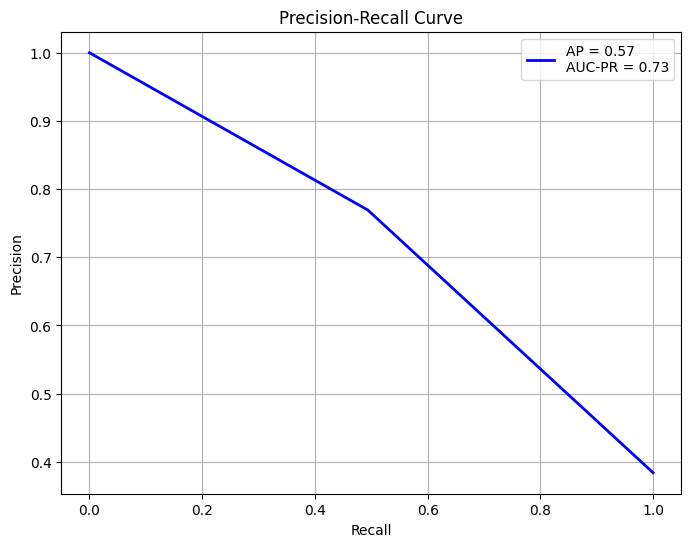

Average Precision (AP): 0.57


In [ ]:
# precision recall curve
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test_encoded, y_pred_)

# Calculate the Average Precision (AP) score
ap_score = average_precision_score(y_test_encoded, y_pred_)
auc_precision_recall = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {ap_score:.2f} \nAUC-PR = {auc_precision_recall:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

print(f"Average Precision (AP): {ap_score:.2f}")